# CS5489 - Machine Learning
# Lecture 7a - Deep Learning
### Dept. of Computer Science, City University of Hong Kong

# Outline
- Going deeper
  - ReLU and Batchnorm
- Optimization methods
- Deep architectures and Image classification
- Transfer learning

In [1]:
# setup
%matplotlib inline
import matplotlib_inline   # setup output image format
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100  # display larger images
import matplotlib
from numpy import *
import numpy as np
from sklearn import *
from scipy import stats
from scipy import signal
import random
import math
from prettytable import PrettyTable

rbow = plt.get_cmap('rainbow')

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import struct
import sys
print(f"Python: {sys.version} PyTorch: {torch.__version__}")

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Python: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:09:02) [GCC 11.2.0] PyTorch: 2.8.0+cu129
Using device: cuda


In [3]:
def plot_history(history): 
    fig, ax1 = plt.subplots()
    
    ax1.plot(history['train_loss'], 'r', label="training loss ({:.6f})".format(history['train_loss'][-1]))
    ax1.plot(history['val_loss'], 'r--', label="validation loss ({:.6f})".format(history['val_loss'][-1]))
    ax1.grid(True)
    ax1.set_xlabel('iteration')
    ax1.legend(loc="best", fontsize=9)    
    ax1.set_ylabel('loss', color='r')
    ax1.tick_params('y', colors='r')

    if 'train_accuracy' in history:
        ax2 = ax1.twinx()

        ax2.plot(history['train_accuracy'], 'b', label="training acc ({:.4f})".format(history['train_accuracy'][-1]))
        ax2.plot(history['val_accuracy'], 'b--', label="validation acc ({:.4f})".format(history['val_accuracy'][-1]))

        ax2.legend(loc="best", fontsize=9)
        ax2.set_ylabel('acc', color='b')        
        ax2.tick_params('y', colors='b')
    plt.show() 

In [4]:
def show_imgs(W_list, nc=10, highlight_green=None, highlight_red=None, titles=None):
    nfilter = len(W_list)
    nr = (nfilter - 1) // nc + 1
    for i in range(nr):
        for j in range(nc):
            idx = i * nc + j
            if idx == nfilter:
                break
            plt.subplot(nr, nc, idx + 1)
            cur_W = W_list[idx]
            plt.imshow(cur_W,cmap='gray', interpolation='nearest')  
            if titles is not None:
                plt.title(titles % idx)
            
            if ((highlight_green is not None) and highlight_green[idx]) or \
               ((highlight_red is not None) and highlight_red[idx]): 
                ax = plt.gca()
                if highlight_green[idx]:
                    mycol = '#00FF00'
                else:
                    mycol = 'r'
                for S in ['bottom', 'top', 'right', 'left']:
                    ax.spines[S].set_color(mycol)
                    ax.spines[S].set_lw(2.0)
                ax.xaxis.set_ticks_position('none')               
                ax.yaxis.set_ticks_position('none')
                ax.set_xticks([])
                ax.set_yticks([])
            else:
                plt.gca().set_axis_off()


In [5]:
def read_32int(f):
    return struct.unpack('>I', f.read(4))[0]
def read_img(img_path):
    with open(img_path, 'rb') as f:
        magic_num = read_32int(f)
        num_image = read_32int(f)
        n_row = read_32int(f)
        n_col = read_32int(f)
        #print 'num_image = {}; n_row = {}; n_col = {}'.format(num_image, n_row, n_col)
        res = []
        npixel = n_row * n_col
        res_arr = fromfile(f, dtype='B')
        res_arr = res_arr.reshape((num_image, n_row, n_col), order='C')
        #print 'image data shape = {}'.format(res_arr.shape)
        return num_image, n_row, n_col, res_arr    
def read_label(label_path):
    with open(label_path, 'rb') as f:
        magic_num = read_32int(f)
        num_label = read_32int(f)
        #print 'num_label = {}'.format(num_label)
        res_arr = fromfile(f, dtype='B')
        #print res_arr.shape
        #res_arr = res_arr.reshape((num_label, 1))
        res_arr = res_arr.ravel()
        #print 'label data shape = {}'.format(res_arr.shape)
        return num_label, res_arr

In [6]:
n_train, nrow, ncol, trainimg = read_img('data/train-images.idx3-ubyte')
_, trainY = read_label('data/train-labels.idx1-ubyte')
n_test, _, _, testimg = read_img('data/t10k-images.idx3-ubyte')
_, testY = read_label('data/t10k-labels.idx1-ubyte')

# for demonstration we only use 10% of the training data
sample_index = range(0, trainimg.shape[0], 10)
trainimg  = trainimg[sample_index]
trainY    = trainY[sample_index]
print(trainimg.shape)
print(trainY.shape)
print(testimg.shape)
print(testY.shape)

(6000, 28, 28)
(6000,)
(10000, 28, 28)
(10000,)


In [7]:
# Convert to PyTorch tensors and scale to 0-1
trainI = torch.from_numpy(trainimg.reshape((6000, 1, 28, 28)) / 255.0).float()
testI = torch.from_numpy(testimg.reshape((10000, 1, 28, 28)) / 255.0).float()

print(trainI.shape)
print(testI.shape)

torch.Size([6000, 1, 28, 28])
torch.Size([10000, 1, 28, 28])


In [8]:
# Generate fixed validation set
from sklearn.model_selection import train_test_split

vtrainI_np, validI_np, vtrainY_np, validY_np = train_test_split(
    trainI.numpy(), trainY, 
    train_size=0.9, test_size=0.1, random_state=4487
)

vtrainI = torch.from_numpy(vtrainI_np).float()
validI = torch.from_numpy(validI_np).float()
vtrainY = torch.from_numpy(vtrainY_np).long()
validY = torch.from_numpy(validY_np).long()

validsetI = (validI, validY)

print(f"Training set: {vtrainI.shape}, {vtrainY.shape}")
print(f"Validation set: {validI.shape}, {validY.shape}")

cid, cfreq = vtrainY.unique(return_counts=True)

print(f"Training set Distribution:", cfreq.numpy().tolist())

Training set: torch.Size([5400, 1, 28, 28]), torch.Size([5400])
Validation set: torch.Size([600, 1, 28, 28]), torch.Size([600])
Training set Distribution: [491, 599, 554, 556, 513, 518, 567, 584, 496, 522]


# Problems with Going Deeper

- **Vanishing Gradient Problem 1**
  - successive multiplications of small gradients gives smaller gradients, and converges to 0
  - the gradients backpropagated to the first few layers has small signal.

- Example: for  4-layers, 

 <center><img src="imgs/deepeg.png" width=600></center>
 
$$\frac{dL}{d \mathbf{a}_j}= \frac{d\mathbf{g}_1^T}{d\mathbf{a}_j} \frac{d\mathbf{z_1}^T}{d\mathbf{g}_1}\frac{d\mathbf{g}_2^T}{d\mathbf{z_1}}\frac{d\mathbf{z_2}^T}{d\mathbf{g}_2}\frac{d\mathbf{g}_3^T}{d\mathbf{z_2}}\frac{d\mathbf{z_3}^T}{d\mathbf{g}_3}\frac{d\mathbf{g}_4^T}{d\mathbf{z_3}}\frac{d\mathbf{f}^T}{d\mathbf{g}_4} \frac{dL}{d\mathbf{f}}
  $$

- **Vanishing Gradient Problem 2**
  - using backprop, the gradient at a node is the summation over $O(H^D)$ paths
    - $D$ is the number of layers to the output layer.
    - $H$ is the number of  nodes in the layer (assuming they all have the same width).    
  - the original loss signal gets "washed out".

<center><img src="imgs/gpaths.png" width=400></center>

- **Dataset Size**
  - a "small" network with just 40 inputs, 30 hidden nodes, and 1 output has ~1200 parameters.
  - if we don't have enough samples:
    - large variance in the parameter estimator  (what you  get may be far from the truth)
    - deeper networks are more complex, which are easier to overfit the training data.

- *How many samples do we need?*    
   - Theorem (Bartlett, Maiorov, Meir, 1998)
> Suppose $\cal N$ is a feed-forward network with $W$ weights, $L$ layers, and all non-output gates having a fixed piecewise-polynomial activation function with a fixed number of pieces (e.g., ReLU). Then $VCdim({\cal N}) = O(WL \log W + WL^2)$.





  - VC dimension is a statistical measure of function class capacity:
    - to achieve certain level of generalization, sample size needs to scale proportionally to VC dim.
    - for the same number of parameters, the deeper network requires more data ($WL^2$).
    - increasing the number of weights, requires a super-linear increase in sample size ($W\log W$).
    

# ReLU activation function
- Rectified Linear Unit: $\mathrm{ReLU}(z) = \max(0,z)$
  - easier to train with: gradient is either 0 or 1.
  - faster: don't need to calculate exponential
  - sparse representation: most nodes will output zero.

In [9]:
x=linspace(-5,5,200)
fs = {'ReLU':    lambda x: maximum(0,x),
     }

actfig = plt.figure(figsize=(5,3))
for name,f in fs.items():
    plt.plot(x, f(x), label=name)
plt.legend(loc="lower right")
plt.axis([-5,5,-0.5,5])
plt.grid(True)
plt.close()


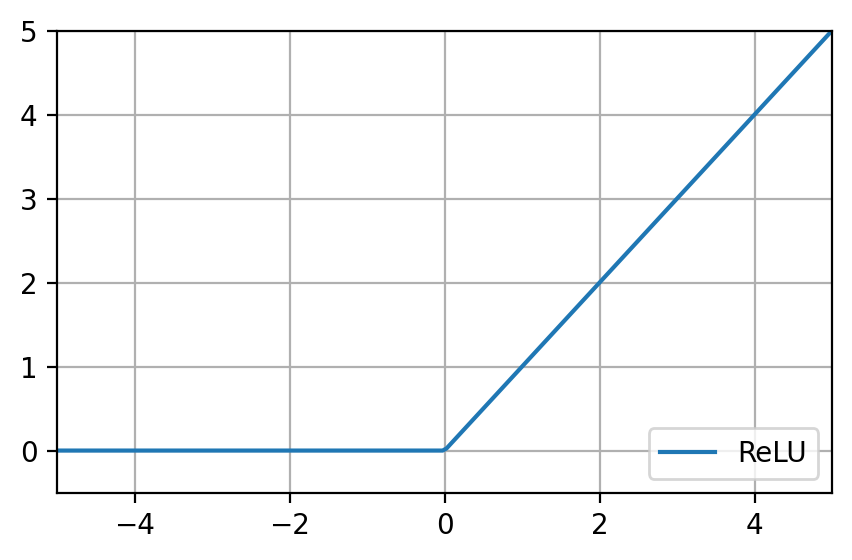

In [10]:
actfig

# Advantage of Sparsity
- if a hidden node $h=0$, then $\frac{dL}{dh}=0$.
  - This blocks some paths when computing the gradients.
  - Gradient signal  is less washed out.
  - Reduces the vanishing gradient problem.
  
<center><img src="imgs/gpaths2.png" width=400></center>

# Better Network Parameterization
- There are equivalent parameterizations of the network by scaling up/down the weights in  successive layers.
  - $f(\mathbf{x}) = \mathbf{A}^T r( \mathbf{B}^T \mathbf{x}) = \frac{1}{\epsilon}\mathbf{A}^T r( \epsilon\mathbf{B}^T \mathbf{x})$
    - $\epsilon>0$ and $r(\cdot)$ is the ReLU activation.
- **Problem:**
  - "internal covariate shift" - change in the distribution of activations during training, due to changes in the parameters.
  
<center><img src="imgs/drift.png" width=200></center>

# Why is it bad?
- suppose, we have a linear network:
 -  $y= x w_1 w_2 w_3 w_4$
 - gradient of each layer is $(g_1, \cdots , g_4)$
- update the parameters with GD:
  - $y = x (w_1-\eta g_1)(w_2-\eta g_2)(w_3-\eta g_3)(w_4-\eta g_4)$
     - there are many  higher-order terms, e.g., $w_1w_2\eta^2g_3g_4$
  - although $w_i$ are updated independently, they strongly affect each other.
  - hence, if the distribution  of activations changes in 1 layer, then all layers are affected, and we need to adjust other layers.

# Solution: Batch Normalization
- For each node in  each layer, normalize the outputs to zero mean and unit variance, *over each mini-batch*.
  - this is analogous to the idea of normalizing the input feature vector to (0,1) Gaussian with  standard ML models!

- Place batchnorm layer after linear transformation.
<center><img src="imgs/batchnorm.png" width=400></center>

  - Let $\{y_i\}_{i=1}^N$ be the output of the linear transform in one minibatch. 
  - For each node  (dimension) in the layer:
    - normalize: $\hat{y}_i = \frac{y_i - \mu}{\sqrt{\sigma^2+\epsilon}}$
      - $\mu,\sigma^2$ are the mean and variance of $\{y_i\}$ in the mini-batch.
      - $\epsilon$ is a small constant for numerical stability.
    - scale-shift: $z_i = \gamma \hat{y}_i+\beta$
      - $\gamma,\beta$ are learnable parameters
      - puts the output in the proper regime of the non-linear activation.
    - The final distribution has mean $\beta$ and variance $\gamma^2$.

- Notes: 
  - batchnorm is applied to each node independently.
  - should put the batchnorm layer after the linear transformation layer.
  - the bias of the linear layer is not necessary since it is removed by batchnorm

- Training:
  - gradients can be computed through the batchnorm layer as usual.
- Training effects:
  - training is accelerated; can use higher learning rates
  - more stable gradients during training
    - increasing the scale of the activations decreases the gradient
    - self-correcting stabilization.
  - better generalization
    - no need for dropout or L2 regularization.

# Example: MNIST
- for each Conv2D/Dense layer:
  - change activation to linear (default); remove bias term
  - append batch-norm and ReLU activation


In [11]:
class DeepCNN(nn.Module):
    def __init__(self, weight_decay=0.0001):
        super(DeepCNN, self).__init__()
        self.weight_decay = weight_decay
        
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5, stride=2, padding=2)
        self.conv2 = nn.Conv2d(10, 40, kernel_size=5, stride=2, padding=2)
        self.conv3 = nn.Conv2d(40, 80, kernel_size=5, stride=1, padding=2)
        self.fc1 = nn.Linear(80 * 7 * 7, 50)  # Adjusted based on input size and strides
        self.fc2 = nn.Linear(50, 10)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = x.view(x.size(0), -1)  # Flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [12]:
# Early stopping implementation
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0001, verbose=1):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_accuracy = 0.0
        self.early_stop = False
        self.verbose = verbose
        
    def __call__(self, current_accuracy):
        if current_accuracy - self.best_accuracy > self.min_delta:
            self.best_accuracy = current_accuracy
            self.counter = 0
        else:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop

In [13]:
# Model Parameter Summarization
def summarize_layer_parameters(model):
    """
    Summarizes the number of parameters in each layer of a PyTorch model.
    """
    trainable_table = PrettyTable(["Module Name", "Parameters"])
    untrainable_table = PrettyTable(["Module Name", "Parameters"])
    total_params = {'train':0,'untrain':0}
    for name, parameter in model.named_parameters():
        if parameter.requires_grad:  # Only count trainable parameters
            params = parameter.numel()
            trainable_table.add_row([name, params])
            total_params['train'] += params
        else:  # Only count untrainable parameters
            params = parameter.numel()
            untrainable_table.add_row([name, params])
            total_params['untrain'] += params
        
    print(trainable_table)
    print(f"\nTotal Trainable Parameters: {total_params['train']}")
    if total_params['untrain'] > 0:
        print(untrainable_table)
    print(f"\nTotal Un-Trainable Parameters: {total_params['untrain']}")

In [14]:
from torch.optim.lr_scheduler import ReduceLROnPlateau,CosineAnnealingLR,ExponentialLR,StepLR,MultiStepLR,LinearLR

# Model Evaluation
def evaluate_model(model, eval_loader, criterion=None):
    model.eval()
    eval_correct = 0
    eval_total = 0
    eval_loss = 0.0
    
    with torch.no_grad():
        for data, target in eval_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, predicted = torch.max(output.data, 1)
            eval_total += target.size(0)
            eval_correct += (predicted == target).sum().item()

            if criterion is not None:
                loss = criterion(output, target)
                eval_loss += loss.item()
    
    eval_accuracy = 100 * eval_correct / eval_total
    avg_eval_loss = eval_loss / len(eval_loader)

    return eval_accuracy if criterion is None else (eval_accuracy, avg_eval_loss)


# Model Training
def train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=100, patience=5, batch_scheduler=None, epoch_scheduler=None):
    history = {
        'train_loss': [], 'val_loss': [],
        'train_accuracy': [], 'val_accuracy': [],
        'learning_rate':[]
    }
    early_stopping = EarlyStopping(patience=patience)
    assert batch_scheduler is None or epoch_scheduler is None
    
    # best_val_loss = float('inf')
    # patience_counter = 0
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            
            # loss = criterion(output, torch.nn.functional.one_hot(target, num_classes=10).float()) also works
            loss = criterion(output, target)
            
            loss.backward()
            optimizer.step()
            if batch_scheduler is not None:
                batch_scheduler.step()
                history['learning_rate'].append(optimizer.state_dict()['param_groups'][0]['lr'])
            
            train_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            train_total += target.size(0)
            train_correct += (predicted == target).sum().item()
        
        train_accuracy = 100 * train_correct / train_total
        avg_train_loss = train_loss / len(train_loader)
        
        # Validation phase
        val_accuracy, avg_val_loss = evaluate_model(model,valid_loader,criterion)
        
        # Store history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_accuracy'].append(train_accuracy / 100)
        history['val_accuracy'].append(val_accuracy / 100)
        

        train_msg = f'  Train Loss: {avg_train_loss:.6f}, Train Acc: {train_accuracy:.2f}%;'
        valid_msg = f'  Val Loss: {avg_val_loss:.6f}, Val Acc: {val_accuracy:.2f}%'
        
        print(f'Epoch {epoch+1}/{epochs}:', train_msg, valid_msg)

        # Check early stopping
        if patience > 0:
            early_stopping(val_accuracy)
            if early_stopping.early_stop:
                print("Early stopping triggered")
                break
            else:
                torch.save(model.state_dict(), 'best_model.pth')
        else:
            torch.save(model.state_dict(), 'best_model.pth')
        if epoch_scheduler is not None:
            if isinstance(epoch_scheduler, ReduceLROnPlateau):
                epoch_scheduler.step(avg_val_loss)
            else:
                epoch_scheduler.step()
            history['learning_rate'].append(optimizer.state_dict()['param_groups'][0]['lr'])

    # Load best model
    model.load_state_dict(torch.load('best_model.pth'))
    return history, model

DeepCNN(
  (conv1): Conv2d(1, 10, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (conv2): Conv2d(10, 40, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (conv3): Conv2d(40, 80, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (fc1): Linear(in_features=3920, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (softmax): Softmax(dim=1)
)
+--------------+------------+
| Module Name  | Parameters |
+--------------+------------+
| conv1.weight |    250     |
|  conv1.bias  |     10     |
| conv2.weight |   10000    |
|  conv2.bias  |     40     |
| conv3.weight |   80000    |
|  conv3.bias  |     80     |
|  fc1.weight  |   196000   |
|   fc1.bias   |     50     |
|  fc2.weight  |    500     |
|   fc2.bias   |     10     |
+--------------+------------+

Total Trainable Parameters: 286940

Total Un-Trainable Parameters: 0
Using device: cuda
Epoch 1/100:   Train Loss: 1.617102, Tra

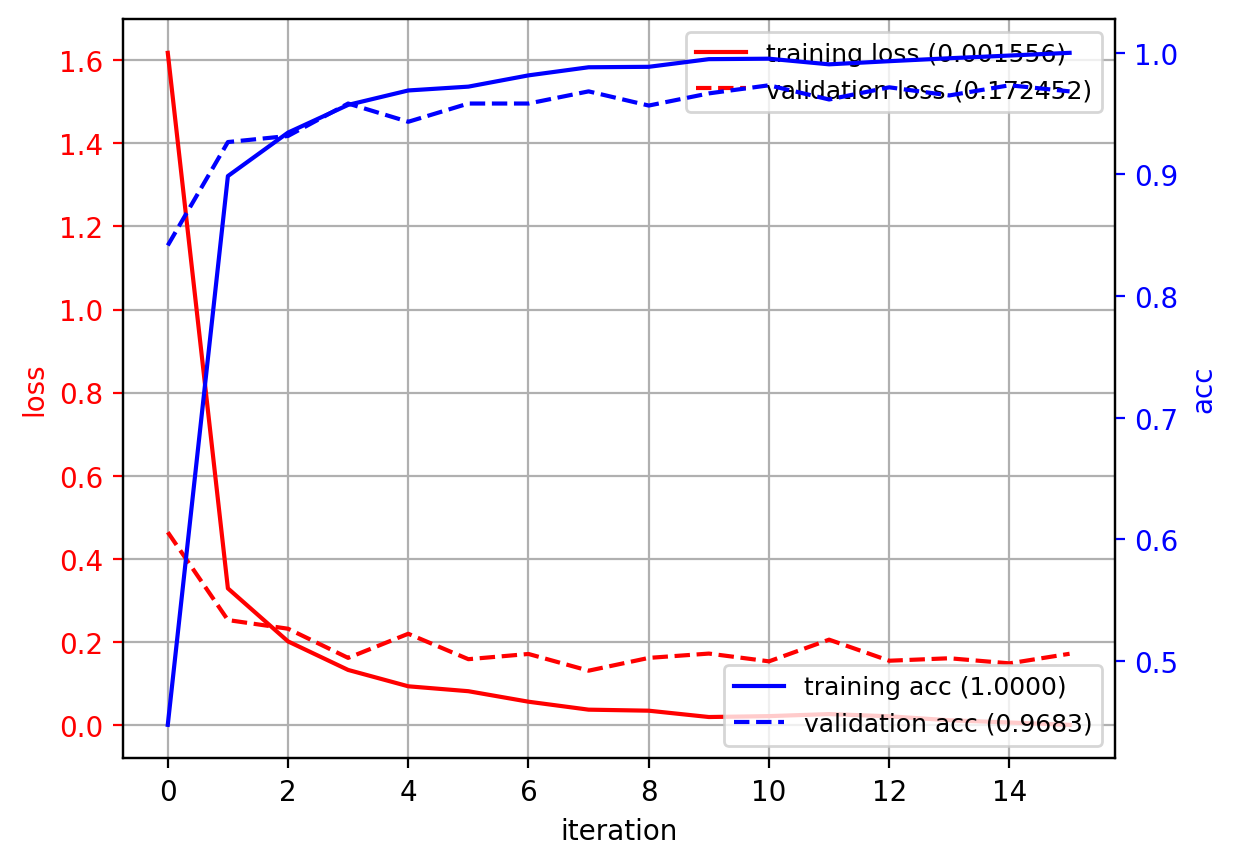

In [15]:
# Initialize random seed
torch.manual_seed(4487)
random.seed(4487)
np.random.seed(4487)
if torch.cuda.is_available():
    torch.cuda.manual_seed(4487)
    torch.backends.cudnn.deterministic = True

# Create model instance
model = DeepCNN()

# Print model architecture
print(model)
summarize_layer_parameters(model)

# Move model to device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using device: {device}")


# Prepare data - ensure correct shape for PyTorch (channel first)
# Assuming vtrainI, vtrainY, validI, validY are already defined as in previous cells

# Convert from (batch, height, width, channels) to (batch, channels, height, width)
if len(vtrainI.shape) == 4 and vtrainI.shape[-1] == 1:  # If shape is (N, 28, 28, 1)
    vtrainI = vtrainI.transpose(0, 3, 1, 2)
    validI = validI.transpose(0, 3, 1, 2)

# Create DataLoaders
batch_size = 50
train_dataset = TensorDataset(vtrainI, vtrainY)
valid_dataset = TensorDataset(validI, validY)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

# Compile the network (equivalent in PyTorch)
criterion = nn.CrossEntropyLoss()  # This includes softmax + cross entropy
optimizer = optim.SGD(model.parameters(), lr=0.02, momentum=0.9, nesterov=True)

# Train the model
history, model = train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=100)

# Plot the training history
plot_history(history)

In [16]:
test_dataset = TensorDataset(testI, torch.from_numpy(testY).long())
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
acc = evaluate_model(model, test_loader)

print("test accuracy:", acc)

test accuracy: 96.7


# Outline
- Going deeper
  - ReLU and Batchnorm
- **Optimization methods**
- Deep architectures and Image classification
- Transfer learning

# Optimization with SGD
- Ideally, we would like to use all the samples to compute the gradient, but this is too time consuming.
- Use a *minibatch* (a few samples) at a time to estimate the gradient.
  - creates an unbiased estimator of the gradient.
  - the variance (expected squared error) depends on the number of samples.
    - i.e., the estimated gradient is *noisy*.

# Learning rates
- **Problem:** For gradient descent, at the minimum we should  have $\frac{dL}{d\mathbf{w}}=0$.
- *What about for SGD?*
  - at the minimum $\frac{dL}{d\mathbf{w}} \neq 0$ because of noise in the gradient.
    - SGD still moves around.

- Solution: reduce the learning rate during the epochs.
  - Examples: for iteration/epoch $k$,
    - **linear change:** $\eta_k = (1-\alpha)\eta_0 + \alpha \eta_T$, where $\alpha = k/T$, and $\eta_0,\eta_T$ given.
    - **decay:** $\eta_k = \frac{1}{1+\delta k} \eta_{0}$, where $0<\delta<1$.
  - we want a small learning rate when we are close to the minimum.
    - needs to be set empirically by examining the learning curves.



# Example: LR decay
- use the built-in `decay` parameter.
  - applied after each batch.

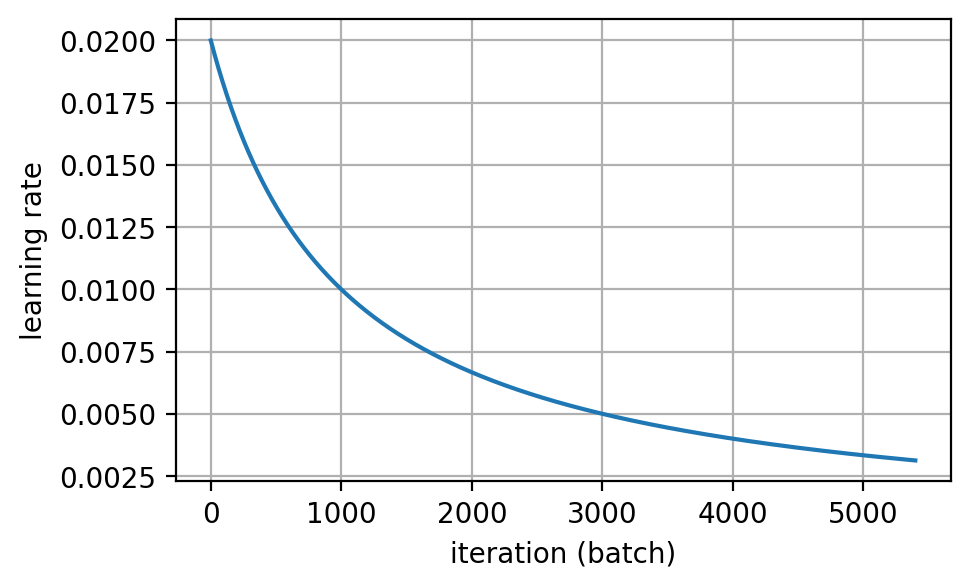

In [17]:
plt.figure(figsize=(5,3))
its = arange(0,50*5400/50)  # 50 epochs, 5400/50 iterations per epoch
lr = 0.02*(1./(1+its*1e-3))
plt.plot(its, lr)
plt.grid(); plt.xlabel('iteration (batch)'); plt.ylabel('learning rate');
plt.show()

In [18]:
# Create model instance
model = DeepCNN()

# Move model to device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using device: {device}")

criterion = nn.CrossEntropyLoss() 
optimizer = optim.SGD(model.parameters(), lr=0.02, momentum=0.9, nesterov=True)
scheduler = ExponentialLR(optimizer, gamma=math.pow(0.95, 1/108))

# Train the model
history, model = train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=50, patience=-1, batch_scheduler=scheduler)

Using device: cuda
Epoch 1/50:   Train Loss: 1.716768, Train Acc: 40.04%;   Val Loss: 0.419060, Val Acc: 88.17%
Epoch 2/50:   Train Loss: 0.325775, Train Acc: 89.72%;   Val Loss: 0.260520, Val Acc: 93.17%
Epoch 3/50:   Train Loss: 0.202823, Train Acc: 93.93%;   Val Loss: 0.179392, Val Acc: 93.50%
Epoch 4/50:   Train Loss: 0.137527, Train Acc: 95.85%;   Val Loss: 0.182461, Val Acc: 95.00%
Epoch 5/50:   Train Loss: 0.091641, Train Acc: 97.06%;   Val Loss: 0.180758, Val Acc: 95.50%
Epoch 6/50:   Train Loss: 0.069151, Train Acc: 97.81%;   Val Loss: 0.158545, Val Acc: 95.00%
Epoch 7/50:   Train Loss: 0.051072, Train Acc: 98.31%;   Val Loss: 0.152725, Val Acc: 96.17%
Epoch 8/50:   Train Loss: 0.030280, Train Acc: 99.13%;   Val Loss: 0.161747, Val Acc: 96.00%
Epoch 9/50:   Train Loss: 0.022639, Train Acc: 99.33%;   Val Loss: 0.173594, Val Acc: 96.33%
Epoch 10/50:   Train Loss: 0.015947, Train Acc: 99.56%;   Val Loss: 0.162648, Val Acc: 96.67%
Epoch 11/50:   Train Loss: 0.011119, Train Acc: 99

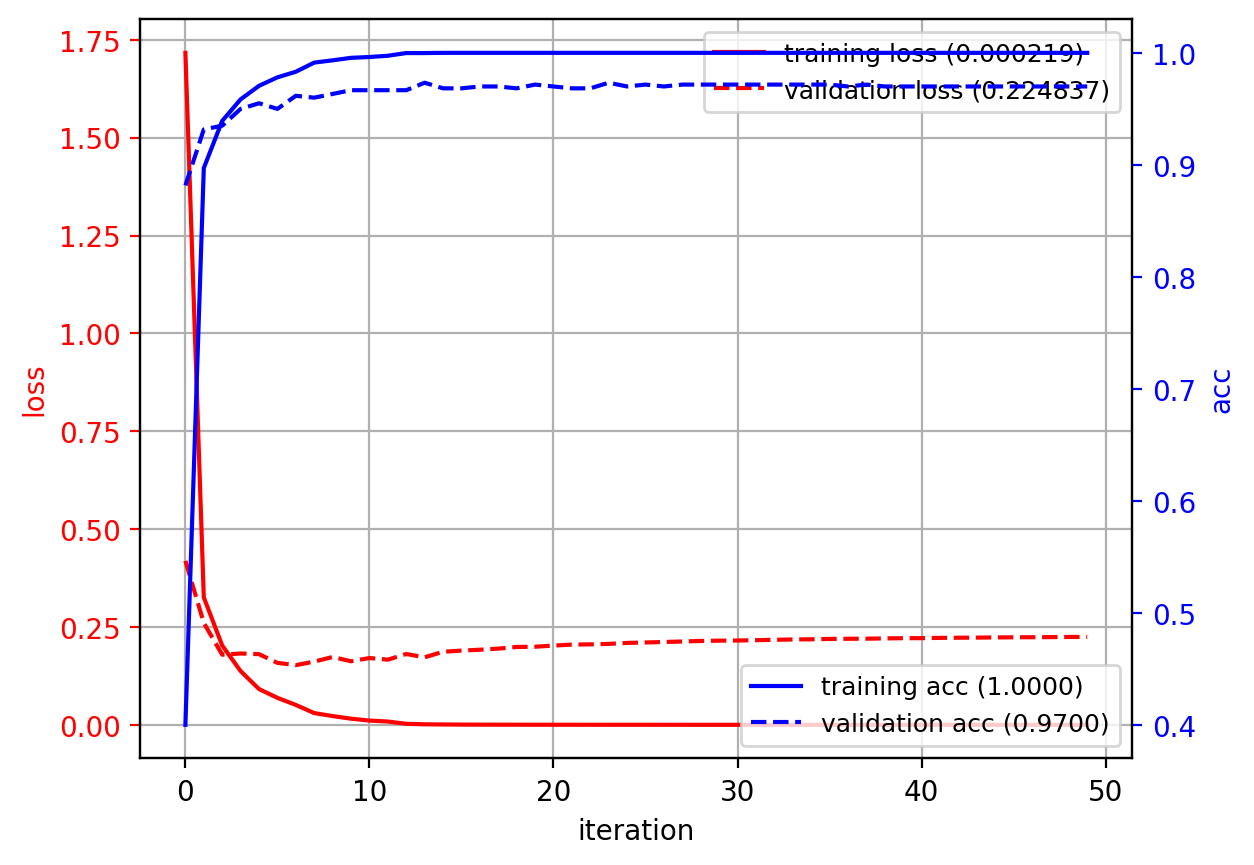

test accuracy: 96.62


In [19]:
# Plot the training history
plot_history(history)

acc = evaluate_model(model, test_loader)
print("test accuracy:", acc)

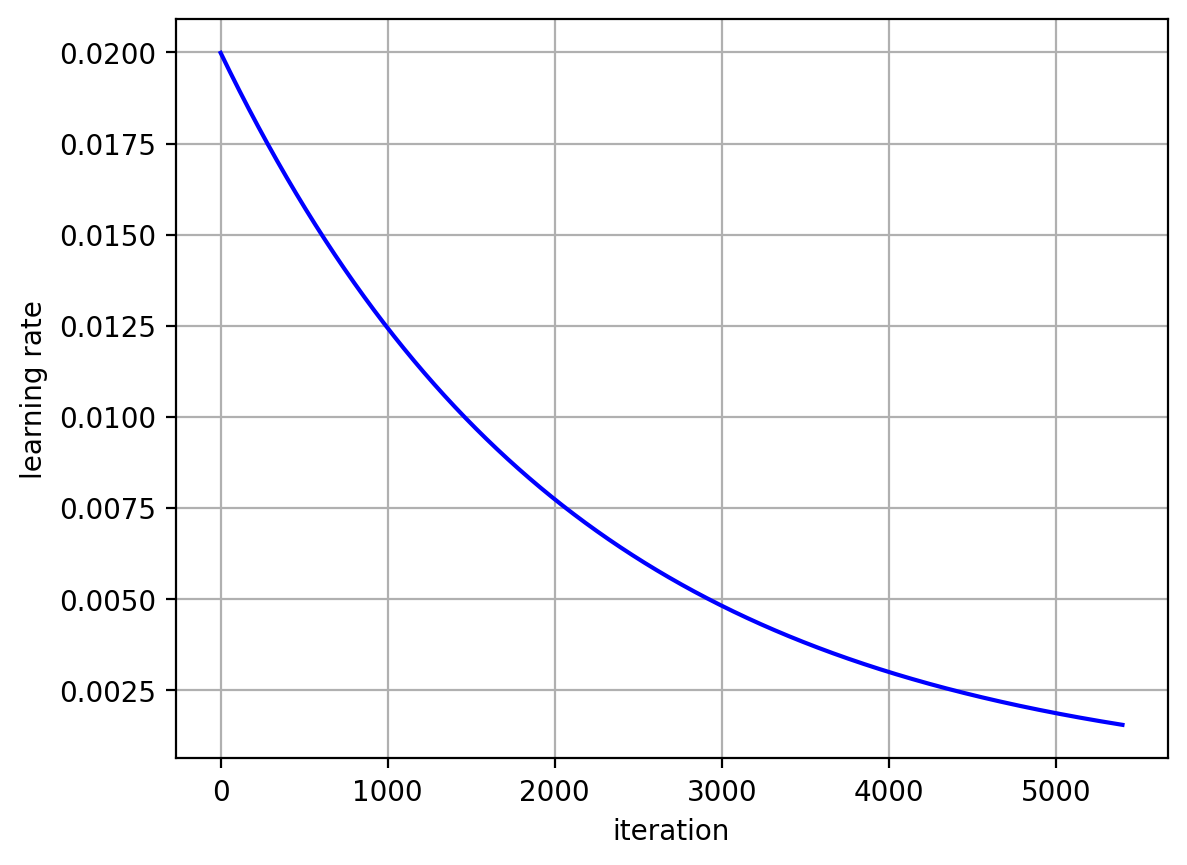

In [20]:
def plot_lr(history): 
    fig, ax1 = plt.subplots()
    
    ax1.plot(history['learning_rate'], 'b')
    ax1.grid(True)
    ax1.set_xlabel('iteration')  
    ax1.set_ylabel('learning rate')

    plt.show() 

plot_lr(history)

# Adaptive schedule
- reduce the learning rate when the validation loss no longer improves
  - similar to early stopping criteria
- implemented as a callback function

In [21]:
# Create model instance
model = DeepCNN()

# Move model to device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using device: {device}")

criterion = nn.CrossEntropyLoss()  # This includes softmax + cross entropy
optimizer = optim.SGD(model.parameters(), lr=0.02, momentum=0.9, nesterov=True)
# reduce LR by a factor of 0.1, if no change in 5 epochs
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

# Train the model
history, model = train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=50, patience=-1, epoch_scheduler=scheduler)

Using device: cuda
Epoch 1/50:   Train Loss: 1.584269, Train Acc: 47.15%;   Val Loss: 0.404391, Val Acc: 87.17%
Epoch 2/50:   Train Loss: 0.313745, Train Acc: 90.24%;   Val Loss: 0.241543, Val Acc: 92.67%
Epoch 3/50:   Train Loss: 0.191844, Train Acc: 93.94%;   Val Loss: 0.236455, Val Acc: 92.83%
Epoch 4/50:   Train Loss: 0.130987, Train Acc: 95.72%;   Val Loss: 0.192679, Val Acc: 94.50%
Epoch 5/50:   Train Loss: 0.097266, Train Acc: 96.61%;   Val Loss: 0.177332, Val Acc: 94.83%
Epoch 6/50:   Train Loss: 0.072049, Train Acc: 97.61%;   Val Loss: 0.172696, Val Acc: 95.00%
Epoch 7/50:   Train Loss: 0.057187, Train Acc: 98.19%;   Val Loss: 0.157365, Val Acc: 95.67%
Epoch 8/50:   Train Loss: 0.051671, Train Acc: 98.46%;   Val Loss: 0.145465, Val Acc: 97.00%
Epoch 9/50:   Train Loss: 0.025971, Train Acc: 99.09%;   Val Loss: 0.254315, Val Acc: 94.50%
Epoch 10/50:   Train Loss: 0.023875, Train Acc: 99.20%;   Val Loss: 0.148523, Val Acc: 96.83%
Epoch 11/50:   Train Loss: 0.016409, Train Acc: 99

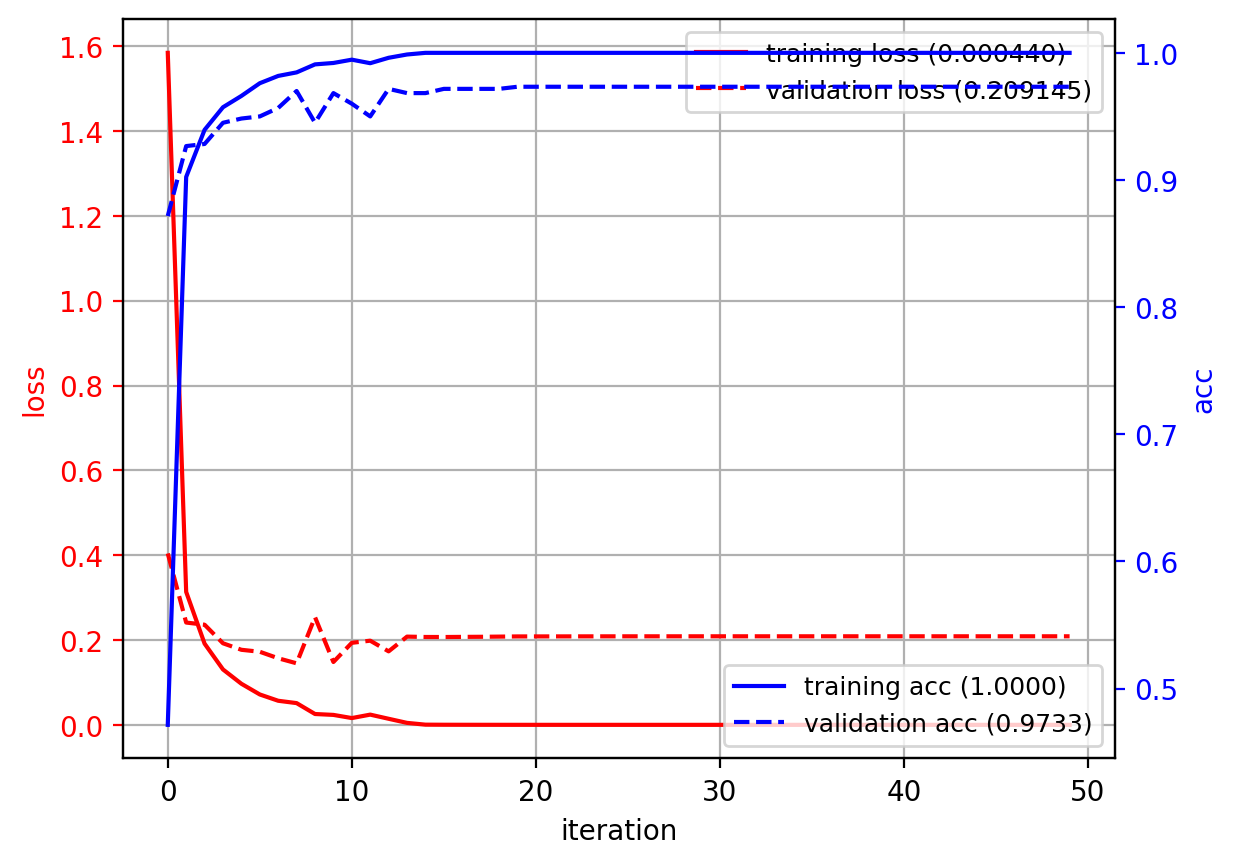

test accuracy: 96.42


In [22]:
# Plot the training history
plot_history(history)

acc = evaluate_model(model, test_loader)
print("test accuracy:", acc)

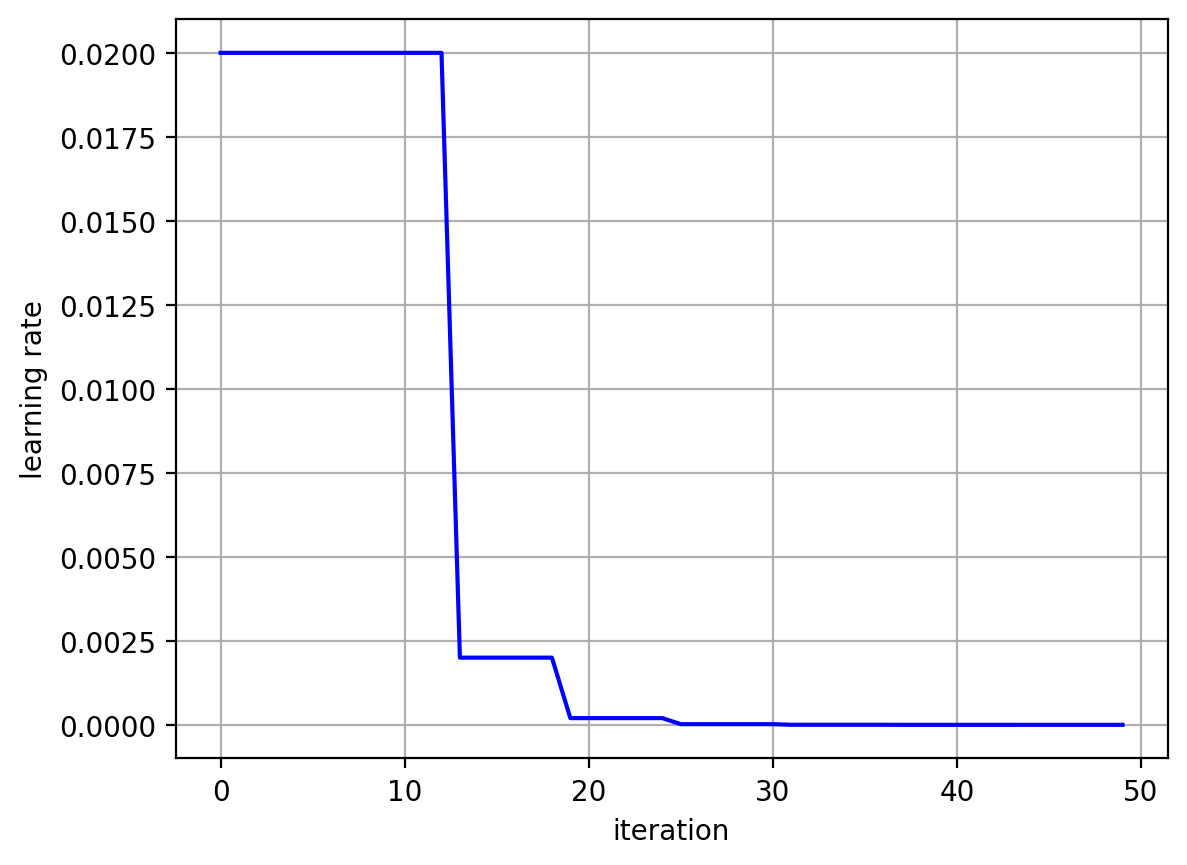

In [23]:
plot_lr(history)

# Fixed schedule
- specify our own schedule using callback `LearningRateScheduler`
- pass a schedule function 
 - inputs are the epoch and current learning rate.
 - outputs the learning rate for this epoch.

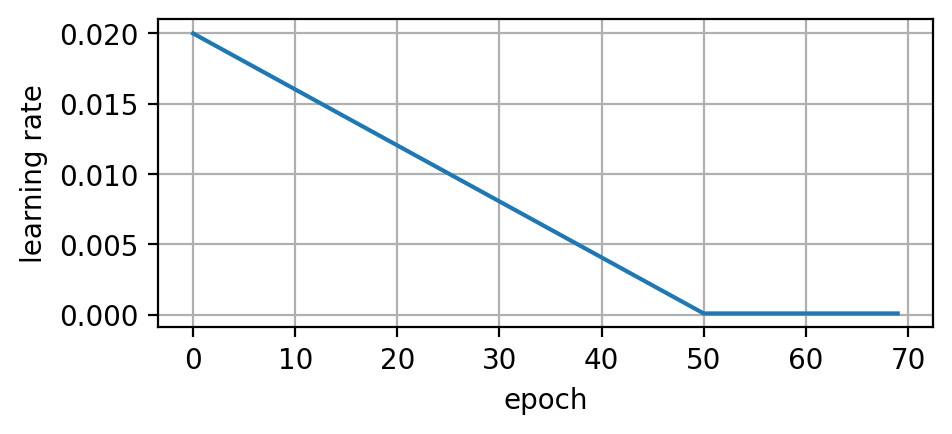

In [24]:
def sc(epoch, curlr):
    alpha = minimum(epoch/50, 1.)
    return 0.02*(1-alpha)+0.0001*alpha
epoch = arange(0,70)
plt.figure(figsize=(5,2))
plt.plot(epoch, sc(epoch,None))
plt.grid(); plt.xlabel('epoch'); plt.ylabel('learning rate');plt.show()

In [25]:
# Create model instance
model = DeepCNN()

# Move model to device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using device: {device}")

criterion = nn.CrossEntropyLoss()  # This includes softmax + cross entropy
optimizer = optim.SGD(model.parameters(), lr=0.02, momentum=0.9, nesterov=True)
# reduce LR by a factor of 0.1, if no change in 5 epochs
scheduler = LinearLR(optimizer, start_factor=1.0, end_factor=0.05, total_iters=50)

# Train the model
history, model = train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=50, patience=-1, epoch_scheduler=scheduler)

Using device: cuda
Epoch 1/50:   Train Loss: 1.561114, Train Acc: 45.91%;   Val Loss: 0.400893, Val Acc: 87.00%
Epoch 2/50:   Train Loss: 0.305708, Train Acc: 90.65%;   Val Loss: 0.233811, Val Acc: 92.83%
Epoch 3/50:   Train Loss: 0.183516, Train Acc: 94.56%;   Val Loss: 0.199219, Val Acc: 94.33%
Epoch 4/50:   Train Loss: 0.128340, Train Acc: 95.87%;   Val Loss: 0.186400, Val Acc: 94.83%
Epoch 5/50:   Train Loss: 0.085602, Train Acc: 97.31%;   Val Loss: 0.175606, Val Acc: 96.00%
Epoch 6/50:   Train Loss: 0.068440, Train Acc: 97.72%;   Val Loss: 0.208534, Val Acc: 95.17%
Epoch 7/50:   Train Loss: 0.053286, Train Acc: 98.31%;   Val Loss: 0.150136, Val Acc: 97.17%
Epoch 8/50:   Train Loss: 0.033672, Train Acc: 99.04%;   Val Loss: 0.166403, Val Acc: 95.33%
Epoch 9/50:   Train Loss: 0.034847, Train Acc: 98.89%;   Val Loss: 0.157852, Val Acc: 96.17%
Epoch 10/50:   Train Loss: 0.019101, Train Acc: 99.43%;   Val Loss: 0.181433, Val Acc: 96.67%
Epoch 11/50:   Train Loss: 0.021414, Train Acc: 99

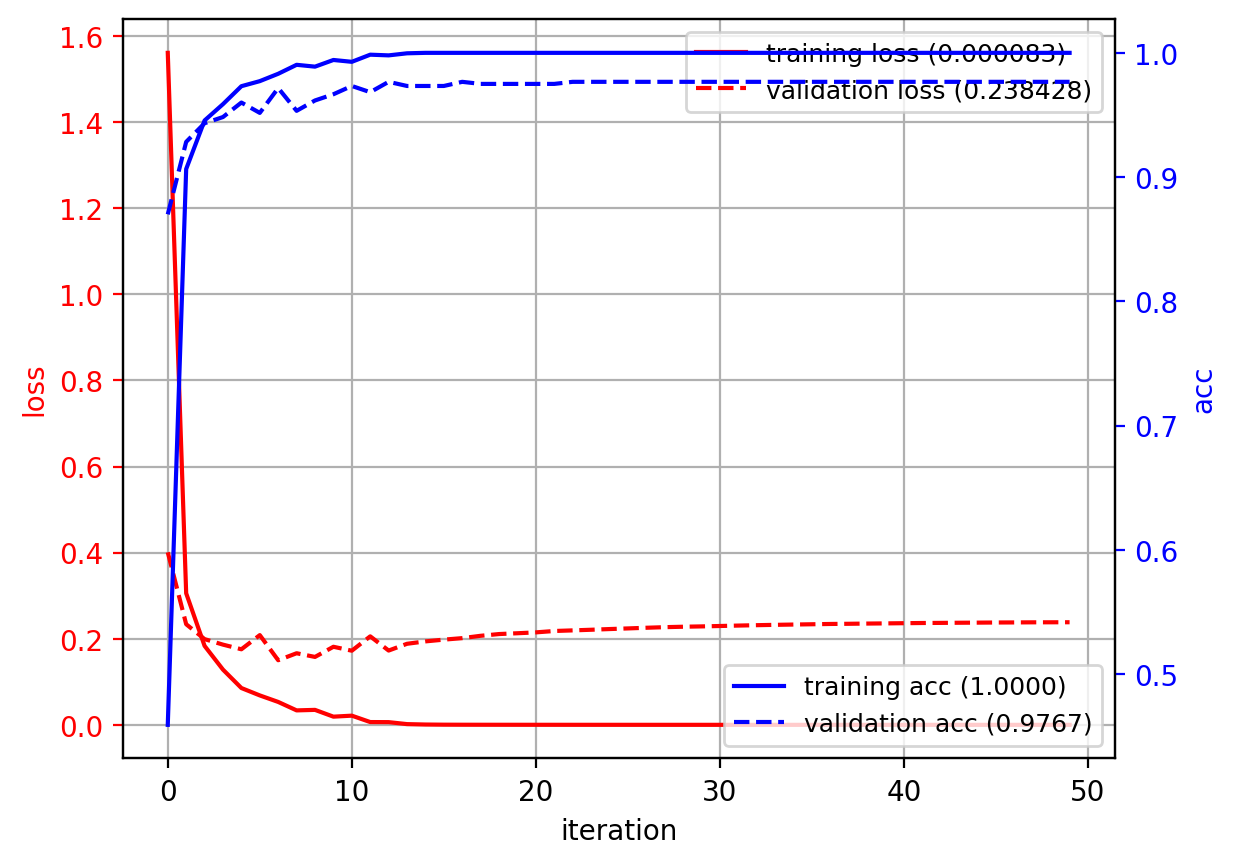

test accuracy: 96.46


In [26]:
# Plot the training history
plot_history(history)

acc = evaluate_model(model, test_loader)
print("test accuracy:", acc)

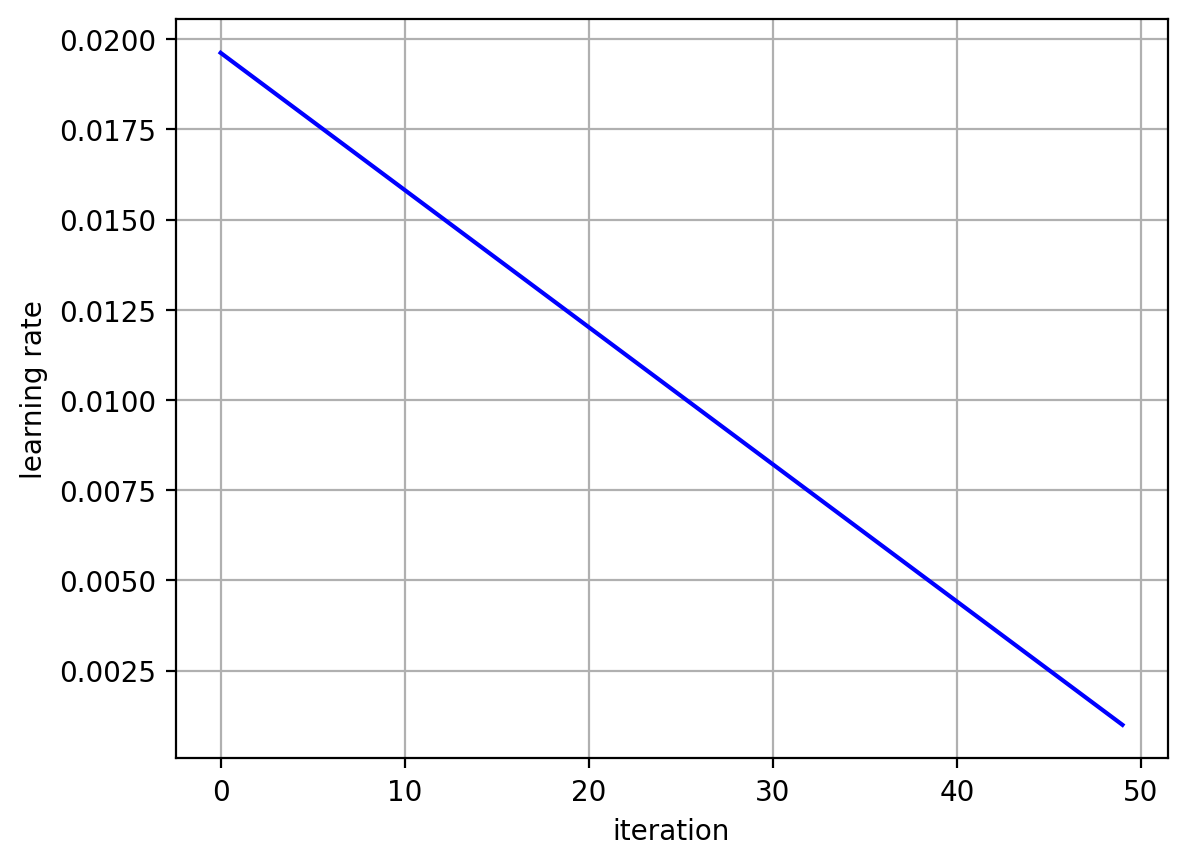

In [27]:
plot_lr(history)

# Momentum
- **Problem**: The estimated gradient is noisy, can jump around.
- **Solution**: keep a running average of the gradients across mini-batches.
  - velocity: $\mathbf{v}^{(t)} = \alpha \mathbf{v}^{(t-1)} - \eta 
  \left.\frac{dL}{d\mathbf{w}}\right\vert_{\mathbf{w}^{(t-1)}}$
    - accumulate the gradients
    - $\alpha$ is the momentum hyperparameter; how much it exponentially decays.
  - parameter update: $\mathbf{w}^{(t)} \leftarrow \mathbf{w}^{(t-1)} + \mathbf{v}^{(t)}$

- Example:
  - red path is using momentum
  - black arrows show the gradient directions at each step
  - without momentum, the path would oscillate wildly.
<center><img src="imgs/momentum.png" width=300></center>

# Nesterov Momentum
- Compute the gradient *after* the current velocity is applied.
  - interim update: $\tilde{\mathbf{w}} = \mathbf{w}^{(t-1)}+\alpha\mathbf{v}^{(t-1)}$
  - velocity: $\mathbf{v}^{(t)} = \alpha \mathbf{v}^{(t-1)} - \eta 
  \left.\frac{dL}{d\mathbf{w}}\right\vert_{\tilde{\mathbf{w}}}$
  - parameter update: $\mathbf{w}^{(t)} \leftarrow \mathbf{w}^{(t-1)} + \mathbf{v}^{(t)}$
- Adds a *correction factor* to improve convergence (for convex batch case)


# Why does SGD work?
- The loss function  has many local minima
- SGD adds "noise" to the true gradient.
  - the noise allows escaping/avoiding/jumping over small local minima.
 

 
- Example:
  - red arrow = true gradient
  - green arrow = added noise
  - black arrow = computed gradient
<center><img src="imgs/sgdeg.png" width=400></center>

# SGD smoothes the loss function
- the added gradient noise is equivalent to convolving the loss function with the noise density.
- higher learning rate $\rightarrow$ larger noise $\rightarrow$ smoother loss
   <center><img src="imgs/sgdsmooth1.png" width=800></center>

- smoother loss removes the local minimum, making it easier to get near the global minimum.
  - but not exactly on it.
  
   <center><img src="imgs/sgdsmooth2.png" width=800></center>

- need to reduce the learning rate in stages to converge to the global  optimum.
   <center><img src="imgs/sgdsmooth3.png" width=800></center>

<center><img src="imgs/sgdsmooth.png" width=1000></center>

# Optimization with Adaptive Learning Rates
- Introduce a separate learning rate for each parameter, and automatically adapt the learning rates during optimization.
- **AdaGrad** (`torch.optim.Adagrad`)
  - adapt individual learning rates by dividing by the square-root of the gradient energy accumulated over the iterations.
    - $\mathbf{g} = \frac{dL}{d\mathbf{w}}$
    - $\mathbf{r}^{(t)} = \mathbf{r}^{(t-1)} + \mathbf{g}^2$
    - $\mathbf{w}^{(t)}  = \mathbf{w}^{(t-1)} -\frac{\eta}{\delta+\sqrt{\mathbf{r}}} \mathbf{g}$
  - (operations are element-wise)
- **RMSProp** (`torch.optim.RMSprop`)
  - use exponential decay on the accumulated energy:
    - $\mathbf{r}^{(t)} = \rho \mathbf{r}^{(t-1)} + (1-\rho)\mathbf{g}^2$


- **Adam** (`torch.optim..Adam`)
  - use momentum with exponential weighting to estimate the gradient and gradient energy.
    - $\mathbf{s}^{(t)}  = \rho_1\mathbf{s}^{(t-1)} + (1-\rho_1) \mathbf{g}$
    - $\mathbf{r}^{(t)}  = \rho_2\mathbf{r}^{(t-1)} + (1-\rho_2) \mathbf{g}^2$
  - adds a bias correction for these two estimates.
    - $\mathbf{\hat{s}}^{(t)} = \frac{1}{1-\rho_1^t}\mathbf{s}^{(t)}$
    - $\mathbf{\hat{r}}^{(t)} = \frac{1}{1-\rho_2^t}\mathbf{r}^{(t)}$
  - update:
    - $\mathbf{w}^{(t)} = \mathbf{w}^{(t-1)} -  \frac{\eta}{\delta+\sqrt{\mathbf{\hat{r}}^{(t)}}}\mathbf{\hat{s}}^{(t)}$


# Example
- change the optimizer when compiling the network.

In [28]:
# Create model instance
model = DeepCNN()

# Move model to device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using device: {device}")

criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model
history, model = train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=100, patience=5)

Using device: cuda
Epoch 1/100:   Train Loss: 1.109883, Train Acc: 61.17%;   Val Loss: 0.340950, Val Acc: 88.17%
Epoch 2/100:   Train Loss: 0.286864, Train Acc: 91.37%;   Val Loss: 0.206138, Val Acc: 94.00%
Epoch 3/100:   Train Loss: 0.197446, Train Acc: 93.81%;   Val Loss: 0.157247, Val Acc: 95.33%
Epoch 4/100:   Train Loss: 0.134986, Train Acc: 95.78%;   Val Loss: 0.156642, Val Acc: 95.00%
EarlyStopping counter: 1 out of 5
Epoch 5/100:   Train Loss: 0.099617, Train Acc: 96.89%;   Val Loss: 0.116509, Val Acc: 95.83%
Epoch 6/100:   Train Loss: 0.072853, Train Acc: 97.80%;   Val Loss: 0.168416, Val Acc: 95.00%
EarlyStopping counter: 1 out of 5
Epoch 7/100:   Train Loss: 0.059275, Train Acc: 98.24%;   Val Loss: 0.122134, Val Acc: 96.83%
Epoch 8/100:   Train Loss: 0.048134, Train Acc: 98.63%;   Val Loss: 0.129905, Val Acc: 96.83%
EarlyStopping counter: 1 out of 5
Epoch 9/100:   Train Loss: 0.051222, Train Acc: 98.43%;   Val Loss: 0.127682, Val Acc: 95.50%
EarlyStopping counter: 2 out of 5

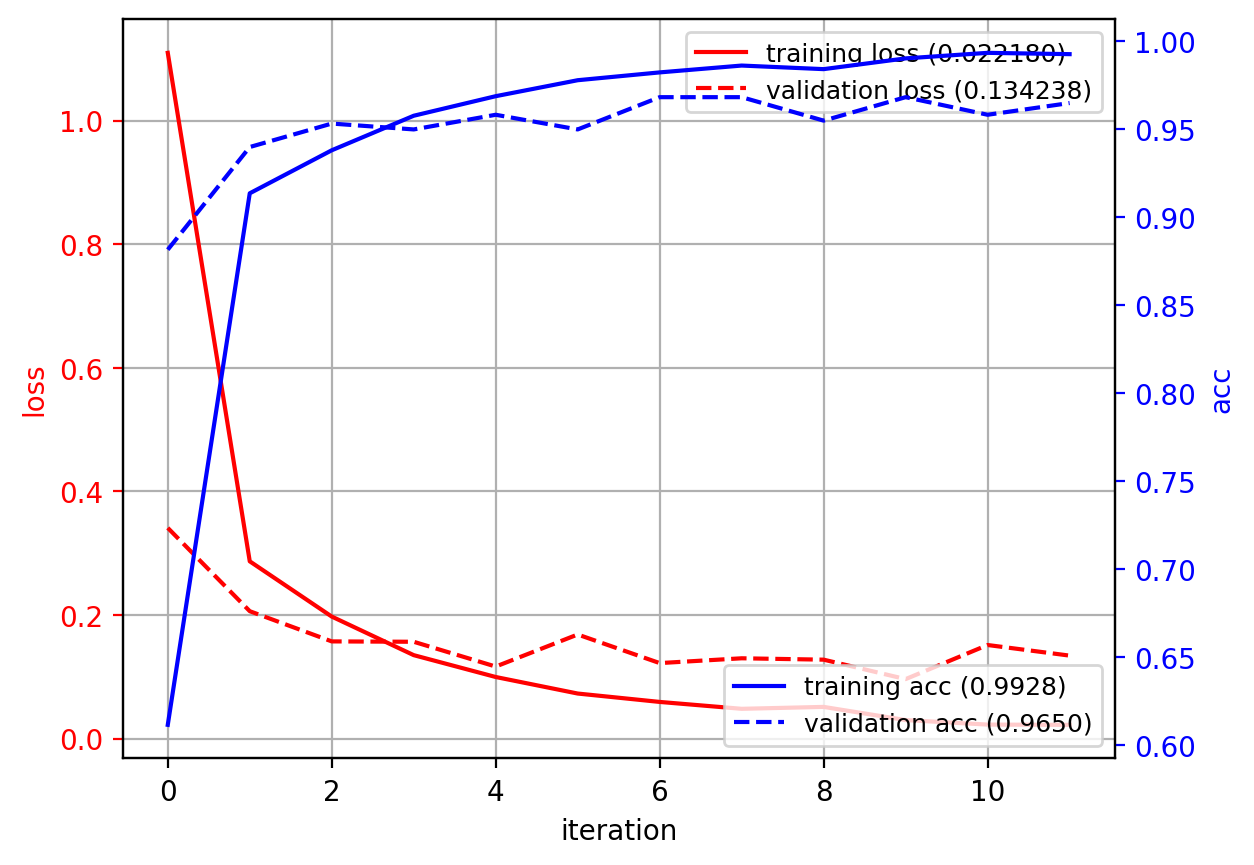

test accuracy: 96.52


In [29]:
# Plot the training history
plot_history(history)

acc = evaluate_model(model, test_loader)
print("test accuracy:", acc)

# Which optimizer is best?
- there's no best optimizer...
- based on the problem and own familiarity with tuning the hyperparmeters.